In [17]:
!pip3 install polars


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import pandas as pd
import polars as pl
import numpy as np
import time
import matplotlib.pyplot as plt

In [19]:
n_rows = 20_000_000
csv_path = 'big_data_csv'

df = pd.DataFrame({
  'id': np.arange(n_rows),
  'category': np.random.choice(['A', 'B', 'C', 'D'], size=n_rows),
  'value1': np.random.rand(n_rows)*100,
  'value2': np.random.rand(n_rows)*1000  
})

df.to_csv(csv_path, index=False)

In [20]:
results = []

def measure_time(label, func):
    start = time.time()
    result = func()
    duration = time.time() - start
    results.append((label, duration))
    return result

In [21]:
df_pd = measure_time('Pandas - read_csv', lambda: pd.read_csv(csv_path))

measure_time('Pandas - filter', lambda: df_pd[df_pd['value1'] > 50])

measure_time('Pandas - groupby mean', lambda: df_pd.groupby('category')['value2'].mean())

measure_time('Pandas - add column', lambda: df_pd.assign(value_sum=df_pd['value1']+df_pd['value2']))

,id,category,value1,value2,value_sum
0,0,A,16.535342,80.358357,96.893699
1,1,A,69.876441,953.336846,1023.213288
2,2,C,51.668955,752.585396,804.254351
3,3,A,52.508059,574.943453,627.451512
4,4,D,26.129854,466.795068,492.924922
...,...,...,...,...,...
19999995,19999995,C,9.815323,861.214301,871.029623
19999996,19999996,A,33.005846,574.089916,607.095762
19999997,19999997,B,50.738924,36.173295,86.912219
19999998,19999998,C,54.108627,585.231996,639.340623


In [22]:
df_pl = measure_time('Polars - read_csv', lambda: pl.read_csv(csv_path))

measure_time('Polars - filter', lambda: df_pl.filter(pl.col('value1') > 50))

measure_time('Polars - groupby mean', lambda: df_pl.group_by('category').agg(pl.col('value2').mean()))

measure_time('Polars - add column', lambda: df_pl.with_columns((pl.col('value1') + pl.col('value2')).alias('value_sum')))

id,category,value1,value2,value_sum
i64,str,f64,f64,f64
0,"""A""",16.535342,80.358357,96.893699
1,"""A""",69.876441,953.336846,1023.213288
2,"""C""",51.668955,752.585396,804.254351
3,"""A""",52.508059,574.943453,627.451512
4,"""D""",26.129854,466.795068,492.924922
…,…,…,…,…
19999995,"""C""",9.815323,861.214301,871.029623
19999996,"""A""",33.005846,574.089916,607.095762
19999997,"""B""",50.738924,36.173295,86.912219


In [23]:
def run_lazy_pipeline():
    df_lazy = pl.read_csv(csv_path).lazy()
    return (
        df_lazy
        .filter(pl.col('value1') > 50)
        .with_columns((pl.col('value1')+pl.col('value2')).alias('value_sum'))
        .group_by('category')
        .agg(pl.col('value2').mean())
        .collect()
    )

In [24]:
measure_time('Polars Lazy - full pipeline', run_lazy_pipeline)

category,value2
str,f64
"""D""",500.20673
"""C""",499.999043
"""B""",500.088423
"""A""",499.874708


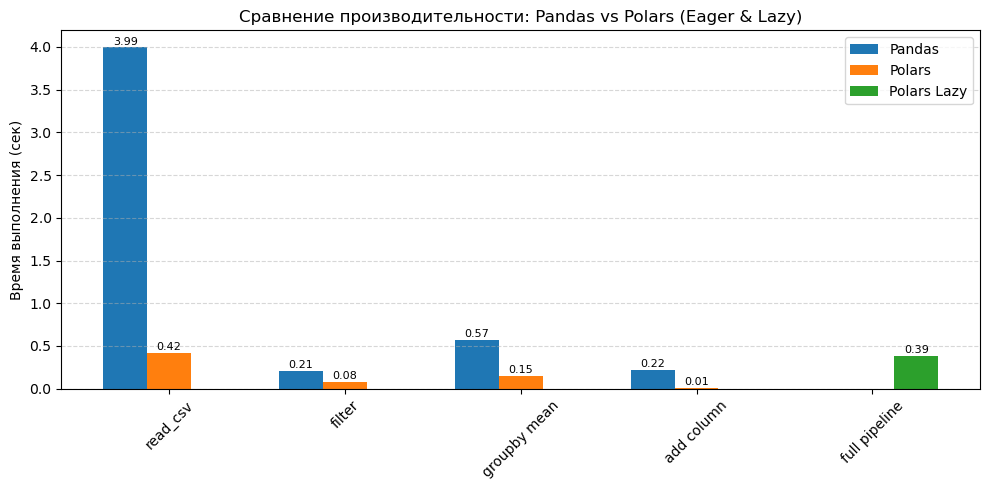

In [26]:
perf_df = pd.DataFrame(results, columns=["Операция", "Время (сек)"])
perf_df["Библиотека"] = perf_df["Операция"].str.split(" - ").str[0]
perf_df["Тип операции"] = perf_df["Операция"].str.split(" - ").str[1]

# Уникальные типы операций, которые хотим отобразить
operation_types = ['read_csv', 'filter', 'groupby mean', 'add column', 'full pipeline']
x = np.arange(len(operation_types))
width = 0.25

# Получение времени выполнения по операциям
def get_times(lib):
    data = perf_df[perf_df["Библиотека"] == lib].set_index("Тип операции")
    return [data.loc[op]["Время (сек)"] if op in data.index else 0 for op in operation_types]

pandas_times = get_times("Pandas")
polars_times = get_times("Polars")
lazy_times = get_times("Polars Lazy")

# Построение группированного графика
plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width, pandas_times, width, label="Pandas")
bars2 = plt.bar(x, polars_times, width, label="Polars")
bars3 = plt.bar(x + width, lazy_times, width, label="Polars Lazy")

# Подписи значений
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

# Настройка графика
plt.xticks(x, operation_types, rotation=45)
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение производительности: Pandas vs Polars (Eager & Lazy)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()